<a href="https://colab.research.google.com/github/Deepu9981/FitPulse-Health-Anomaly-Detection-from-Fitness-Devices/blob/main/Preprocess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [123]:
import pandas as pd
import numpy as np

In [124]:
from google.colab import files

uploaded = files.upload()

Saving FitPulse_wearable_device_data.csv to FitPulse_wearable_device_data (4).csv


# 1. Load Data (CSV / JSON)

In [125]:
def load_data(uploaded_file):
    if uploaded_file.name.endswith(".csv"):
        df = pd.read_csv(uploaded_file, encoding="utf-8", engine="python")
    elif uploaded_file.name.endswith(".json"):
        df = pd.read_json(uploaded_file)
    else:
        raise ValueError("Unsupported file format")

    return df

In [126]:
print("Columns:\n", df.columns)

Columns:
 Index(['Patient_ID', 'heart_rate', 'step_count', 'sleep_tracking',
       'time_stamp', 'Weight', 'Height', 'gender', 'age', 'daily_calories',
       'daily_sleep_hours', 'daily_steps', 'resting_heart_rate'],
      dtype='object')


In [127]:
print("Shape:", df.shape)

Shape: (7909, 13)


In [128]:
print("\nHead:")
display(df.head())


Head:


,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93


In [129]:
print("\nTail:")
display(df.tail())


Tail:


,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
7904,P8668,62.973343,8.0,NaN,2025-01-19 00:35:00,88,163,M,26,2965,7.9,9876,87
7905,P8669,86.473075,43.0,NaN,2025-01-19 17:10:00,77,163,F,25,2127,7.4,9526,97
7906,P8670,66.679417,10.0,NaN,2025-01-03 23:40:00,68,175,F,53,1830,7.9,9543,67
7907,P8671,61.162288,13.0,NaN,2025-01-26 05:50:00,73,178,M,24,2554,7.3,8869,89
7908,P0892,69.301393,49.0,NaN,2025-01-30 04:50:00,71,171,F,34,1999,7.5,8146,84


# 2. Detect Timestamp Column

In [130]:
def detect_timestamp_column(df):
    possible_time_cols = [
        "timestamp", "time", "datetime", "date",
        "created_at", "start_time", "ts"
    ]

    for col in df.columns:
        if col.lower() in possible_time_cols:
            return col

    # fallback: first datetime-like column
    for col in df.columns:
        try:
            pd.to_datetime(df[col])
            return col
        except:
            pass

    raise ValueError("No timestamp column found")


In [131]:
display(df)

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7904,P8668,62.973343,8.0,NaN,2025-01-19 00:35:00,88,163,M,26,2965,7.9,9876,87
7905,P8669,86.473075,43.0,NaN,2025-01-19 17:10:00,77,163,F,25,2127,7.4,9526,97
7906,P8670,66.679417,10.0,NaN,2025-01-03 23:40:00,68,175,F,53,1830,7.9,9543,67
7907,P8671,61.162288,13.0,NaN,2025-01-26 05:50:00,73,178,M,24,2554,7.3,8869,89


In [132]:
# Min, Median, Mode
print("\nMinimum values:\n", df.min(numeric_only=True))
print("\nMedian values:\n", df.median(numeric_only=True))
print("\nMode values:\n", df.mode().iloc[0])



Minimum values:
 heart_rate              40.11805
step_count               0.00000
sleep_tracking               NaN
Weight                  50.00000
Height                 150.00000
age                     15.00000
daily_calories        1600.00000
daily_sleep_hours        7.00000
daily_steps           6002.00000
resting_heart_rate      60.00000
dtype: float64

Median values:
 heart_rate              72.188181
step_count              25.000000
sleep_tracking                NaN
Weight                  70.000000
Height                 169.000000
age                     42.000000
daily_calories        2190.000000
daily_sleep_hours        8.100000
daily_steps           8816.000000
resting_heart_rate      80.000000
dtype: float64

Mode values:
 Patient_ID                          P0892
heart_rate                      51.888529
step_count                           30.0
sleep_tracking                        NaN
time_stamp            2025-01-02 05:05:00
Weight                               75.

In [133]:
print("Heart Rate Variance:", np.var(df["resting_heart_rate"]))
print("Heart Rate Std Dev:", np.std(df["resting_heart_rate"]))


Heart Rate Variance: 139.07205487838215
Heart Rate Std Dev: 11.79288153414517


In [134]:
print("90th Percentile of Age:", np.percentile(df["age"], 90))


90th Percentile of Age: 65.0


In [135]:
# Correlation between Heart Rate and Steps
corr = np.corrcoef(df["resting_heart_rate"], df["daily_steps"])
print("Correlation Matrix:\n", corr)

# Covariance between Heart Rate and Calories
cov = np.cov(df["resting_heart_rate"], df["daily_calories"])
print("Covariance Matrix:\n", cov)


Correlation Matrix:
 [[ 1.00000000e+00 -9.51150891e-04]
 [-9.51150891e-04  1.00000000e+00]]
Covariance Matrix:
 [[1.39089641e+02 4.50435657e+01]
 [4.50435657e+01 1.65932773e+05]]


In [136]:
# Count height > 180
count_high = np.sum(df["Height"] > 180)
print("People with height > 180:", count_high)

People with height > 180: 1686


In [137]:
# Rows 5 to 7
display(df.loc[5:7, ["Patient_ID", "age", "daily_sleep_hours"]])

# Rows 0 to 5
display(df.loc[0:5])

# Sleep duration > 7 hours
display(df.loc[df["daily_sleep_hours"] > 7, ["Patient_ID", "daily_sleep_hours"]])


,Patient_ID,age,daily_sleep_hours
5,P0007,43,7.2
6,P0008,69,8.3
7,P0009,31,8.2


,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
1,P0002,90.833116,6.0,NaN,2025-01-21 08:55:00,78,162,M,20,2719,9.0,9841,86
2,P0003,61.270774,40.0,NaN,2025-01-17 07:10:00,64,162,M,58,2761,8.6,8669,63
3,P0005,59.807869,29.0,NaN,2025-01-18 18:25:00,70,151,M,38,2854,8.6,9461,91
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93
5,P0007,73.489796,22.0,NaN,2025-01-07 03:55:00,68,171,M,43,2614,7.2,9210,66


,Patient_ID,daily_sleep_hours
0,P0001,7.9
1,P0002,9.0
2,P0003,8.6
3,P0005,8.6
4,P0006,8.4
...,...,...
7904,P8668,7.9
7905,P8669,7.4
7906,P8670,7.9
7907,P8671,7.3


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7909 entries, 0 to 7908
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          7909 non-null   object 
 1   heart_rate          7909 non-null   float64
 2   step_count          7909 non-null   float64
 3   sleep_tracking      0 non-null      float64
 4   time_stamp          7909 non-null   object 
 5   Weight              7909 non-null   int64  
 6   Height              7909 non-null   int64  
 7   gender              7909 non-null   object 
 8   age                 7909 non-null   int64  
 9   daily_calories      7909 non-null   int64  
 10  daily_sleep_hours   7909 non-null   float64
 11  daily_steps         7909 non-null   int64  
 12  resting_heart_rate  7909 non-null   int64  
dtypes: float64(4), int64(6), object(3)
memory usage: 803.4+ KB


# 3. Detect or Create ID Column

In [139]:
def detect_id_column(df):
    for col in df.columns:
        if col.lower() in ["Patient_ID"]:
            return col

    # If no ID column, create single-user ID
    df["id"] = 1
    return "id"

In [140]:
# Fill numeric NaNs with median
df.fillna(df.median(numeric_only=True), inplace=True)

In [141]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (7909, 13)


# 4. Clean & Normalize Data

In [142]:
def clean_data(df, resample_freq="1T"):
    # Detect columns
    time_col = detect_timestamp_column(df)
    id_col = detect_id_column(df)

    # Rename for consistency
    df = df.rename(columns={
        time_col: "timestamp",
        id_col: "id"
    })

    # Convert timestamp
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"])

    # Sort
    df = df.sort_values(["id", "timestamp"])

    # Keep only numeric metrics
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "id"]

    df = df[["id", "timestamp"] + numeric_cols]


In [143]:
# Calories > 2000 and Weight > 80
filtered_df = df[(df["daily_calories"] > 2000) & (df["Weight"] > 80)]
display(filtered_df)

,Patient_ID,heart_rate,step_count,sleep_tracking,time_stamp,Weight,Height,gender,age,daily_calories,daily_sleep_hours,daily_steps,resting_heart_rate
0,P0001,74.499653,26.0,NaN,2025-01-14 16:50:00,88,168,M,22,2808,7.9,8337,72
4,P0006,92.702179,34.0,NaN,2025-01-13 07:20:00,88,159,F,63,2017,8.4,6470,93
10,P0012,69.533211,43.0,NaN,2025-01-18 04:15:00,85,169,M,40,2813,8.8,9485,65
11,P0013,49.953666,21.0,NaN,2025-01-16 19:55:00,89,164,M,33,2651,7.4,8668,61
18,P0020,45.855015,32.0,NaN,2025-01-05 16:25:00,87,165,M,61,2951,7.2,7908,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7879,P8642,69.159325,34.0,NaN,2025-01-07 14:15:00,86,162,M,36,2345,8.7,8674,72
7880,P8643,87.629262,24.0,NaN,2025-01-17 04:10:00,81,178,M,53,2736,8.3,9803,93
7888,P8651,76.461096,13.0,NaN,2025-01-23 05:00:00,89,150,F,19,2165,7.5,9867,93
7902,P8666,77.640206,41.0,NaN,2025-01-22 18:05:00,87,159,M,52,2770,7.4,8665,64


# 5. Resample per ID

In [144]:
def resample_data(df, resample_freq="1T"):
    resampled = []
    for uid, group in df.groupby("id"):
        g = (
            group
            .set_index("timestamp")
            .resample(resample_freq)
            .mean()
            .interpolate(method="time")
            .ffill()
            .bfill()
            .reset_index()
        )
        g["id"] = uid
        resampled.append(g)

    df_final = pd.concat(resampled, ignore_index=True)

    return df_final

In [162]:
df['sleep_tracking']

,sleep_tracking
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
7904,NaN
7905,NaN
7906,NaN
7907,NaN


In [165]:
print("Unique values in 'sleep_tracking' column:")
print(df['sleep_tracking'].unique())

Unique values in 'sleep_tracking' column:
['awake' 'exercise' 'sleep' '??']


In [146]:
df.to_csv("FitPulse_final_dataset.csv", index=False)


In [147]:
output_path = "FitPulse_final_dataset.csv"
df.to_csv(output_path, index=False)

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# visualization

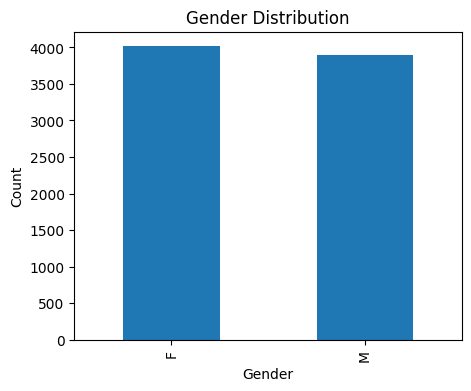

In [150]:
#Bar Chart – Gender Count
plt.figure(figsize=(5,4))
df["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


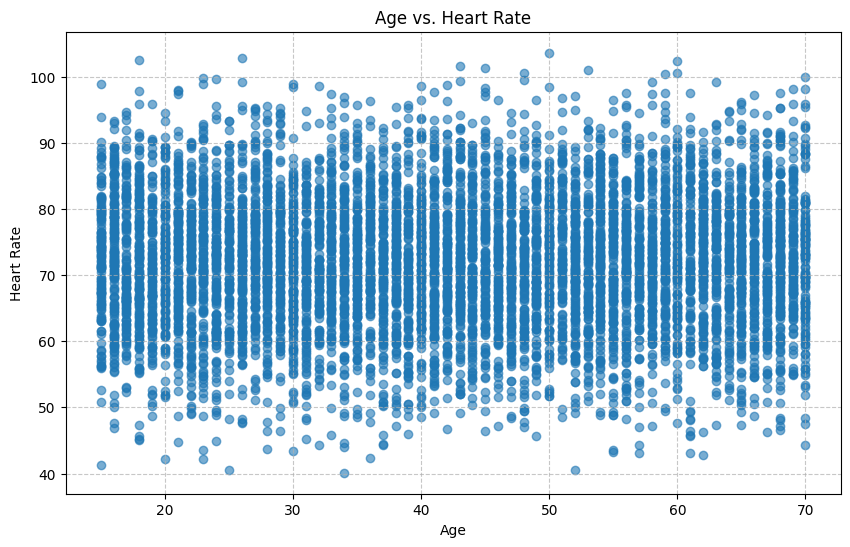

In [151]:
#avg heart rate
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df['age'], df['heart_rate'], alpha=0.6)
plt.title('Age vs. Heart Rate')
plt.xlabel('Age')
plt.ylabel('Heart Rate')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

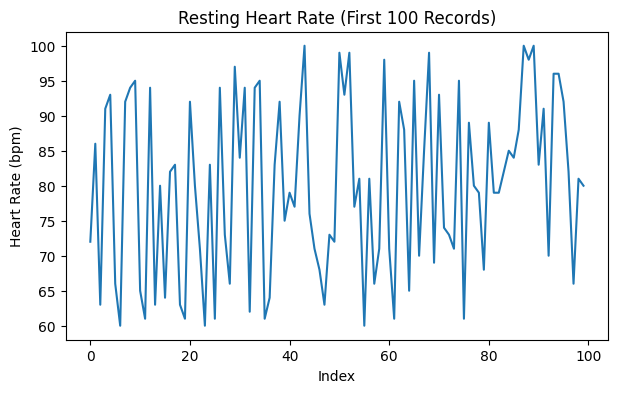

In [152]:
#Line Plot – Heart Rate Over Records
plt.figure(figsize=(7,4))
plt.plot(df["resting_heart_rate"].head(100))
plt.title("Resting Heart Rate (First 100 Records)")
plt.xlabel("Index")
plt.ylabel("Heart Rate (bpm)")
plt.show()


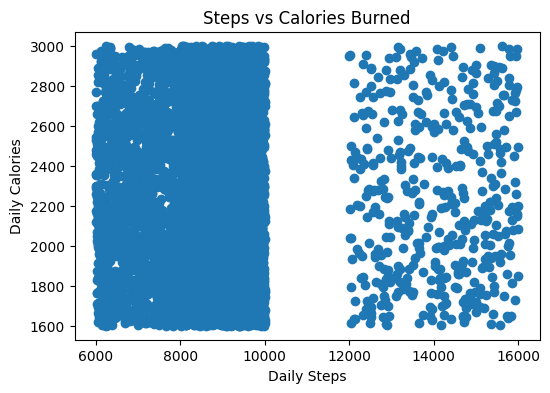

In [153]:
#Scatter Plot – Steps vs Calories
plt.figure(figsize=(6,4))
plt.scatter(df["daily_steps"], df["daily_calories"])
plt.title("Steps vs Calories Burned")
plt.xlabel("Daily Steps")
plt.ylabel("Daily Calories")
plt.show()
